# Notebook 2: Person Data — Demographics, Ability & Covariates

This notebook explores **`data_persons.csv`** — the 881 simulated students and their properties.

**Person properties:**
- Gender (0=female, 1=male)
- Program (1=Hauptschule, 2=Integrated, 3=Realschule, 4=Gymnasium)
- HiSES (socio-economic status, standardized)
- theta_true (true latent ability — known because we simulated the data)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', message='vert.*deprecated.*orientation')
warnings.filterwarnings('ignore', message='set_ticklabels.*should only be used')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Raw Data: `data_persons.csv`

First 20 rows, then tail, then full summary.

In [2]:
persons = pd.read_csv('data_persons.csv')
print(f'Shape: {persons.shape[0]} persons × {persons.shape[1]} columns')
print(f'Columns: {list(persons.columns)}')
print()
persons.head(20)

Shape: 881 persons × 5 columns
Columns: ['person_id', 'gender', 'program', 'hises', 'theta_true']



,person_id,gender,program,hises,theta_true
0,0,0,3,0.7421,1.7045
1,1,0,3,0.2993,-0.8160
2,2,0,4,1.3017,2.1120
3,3,1,4,1.5615,1.7896
4,4,0,3,0.0320,0.5197
5,5,1,2,-0.7534,0.1339
6,6,1,3,0.4600,0.4932
7,7,0,3,-0.6777,-0.1086
8,8,1,2,2.0134,0.4306
9,9,0,3,0.1365,-0.2826


In [3]:
persons.tail(10)

,person_id,gender,program,hises,theta_true
871,871,0,4,0.3636,2.4416
872,872,1,2,0.8869,-0.6585
873,873,0,4,-0.4208,1.8934
874,874,0,3,-2.6042,-0.1599
875,875,1,2,0.1989,0.7329
876,876,0,4,0.4367,-0.0639
877,877,0,1,0.4043,-0.6003
878,878,0,4,1.2358,1.3437
879,879,0,3,-1.0711,0.7196
880,880,0,3,0.6802,1.1008


In [4]:
persons.info()
print()
persons.describe().round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   person_id   881 non-null    int64  
 1   gender      881 non-null    int64  
 2   program     881 non-null    int64  
 3   hises       881 non-null    float64
 4   theta_true  881 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.5 KB



,person_id,gender,program,hises,theta_true
count,881.000,881.000,881.000,881.000,881.000
mean,440.000,0.501,2.838,0.039,0.753
std,254.467,0.500,1.148,0.989,1.200
min,0.000,0.000,1.000,-3.020,-3.536
25%,220.000,0.000,2.000,-0.612,-0.090
50%,440.000,1.000,3.000,0.019,0.722
75%,660.000,1.000,4.000,0.697,1.643
max,880.000,1.000,4.000,3.193,4.227


## 2. Categorical Variables: Gender & Program

These are the **person predictors** used in the Latent Regression Rasch model.

In [5]:
# Gender distribution
gender_counts = persons['gender'].value_counts().sort_index()
gender_labels = {0: 'Female', 1: 'Male'}
print('Gender distribution:')
for g, c in gender_counts.items():
    print(f'  {gender_labels[g]}: {c} ({c/len(persons)*100:.1f}%)')

print()

# Program distribution
prog_counts = persons['program'].value_counts().sort_index()
prog_labels = {1: 'Hauptschule (lowest)', 2: 'Integrated', 3: 'Realschule (middle)', 4: 'Gymnasium (highest)'}
print('Program distribution:')
for p, c in prog_counts.items():
    print(f'  {p} — {prog_labels[p]}: {c} ({c/len(persons)*100:.1f}%)')

Gender distribution:
  Female: 440 (49.9%)
  Male: 441 (50.1%)

Program distribution:
  1 — Hauptschule (lowest): 192 (21.8%)
  2 — Integrated: 87 (9.9%)
  3 — Realschule (middle): 274 (31.1%)
  4 — Gymnasium (highest): 328 (37.2%)


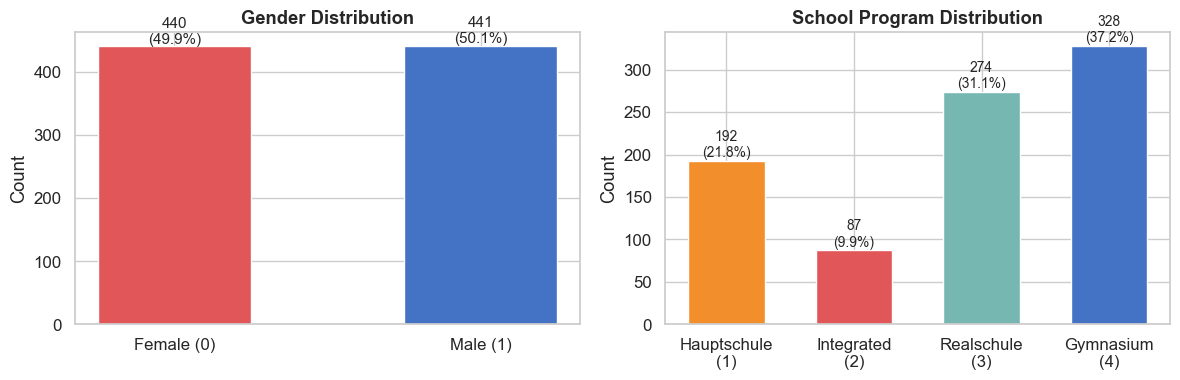

In [6]:
# ── Bar charts for categorical variables ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
colors_g = ['#E15759', '#4472C4']
bars = ax.bar(['Female (0)', 'Male (1)'], gender_counts.values, color=colors_g, edgecolor='white', width=0.5)
for bar, val in zip(bars, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(persons)*100:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Count'); ax.set_title('Gender Distribution', fontweight='bold')

ax = axes[1]
colors_p = ['#F28E2B', '#E15759', '#76B7B2', '#4472C4']
labels_p = ['Hauptschule\n(1)', 'Integrated\n(2)', 'Realschule\n(3)', 'Gymnasium\n(4)']
bars = ax.bar(labels_p, prog_counts.values, color=colors_p, edgecolor='white', width=0.6)
for bar, val in zip(bars, prog_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(persons)*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Count'); ax.set_title('School Program Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Cross-tabulation: Gender × Program
ct = pd.crosstab(persons['program'], persons['gender'], margins=True)
ct.columns = ['Female', 'Male', 'Total']
ct.index = [prog_labels.get(i, i) for i in ct.index]
ct

,Female,Male,Total
Hauptschule (lowest),90,102,192
Integrated,35,52,87
Realschule (middle),147,127,274
Gymnasium (highest),168,160,328
All,440,441,881


## 3. Continuous Variables: HiSES & True Ability (θ)

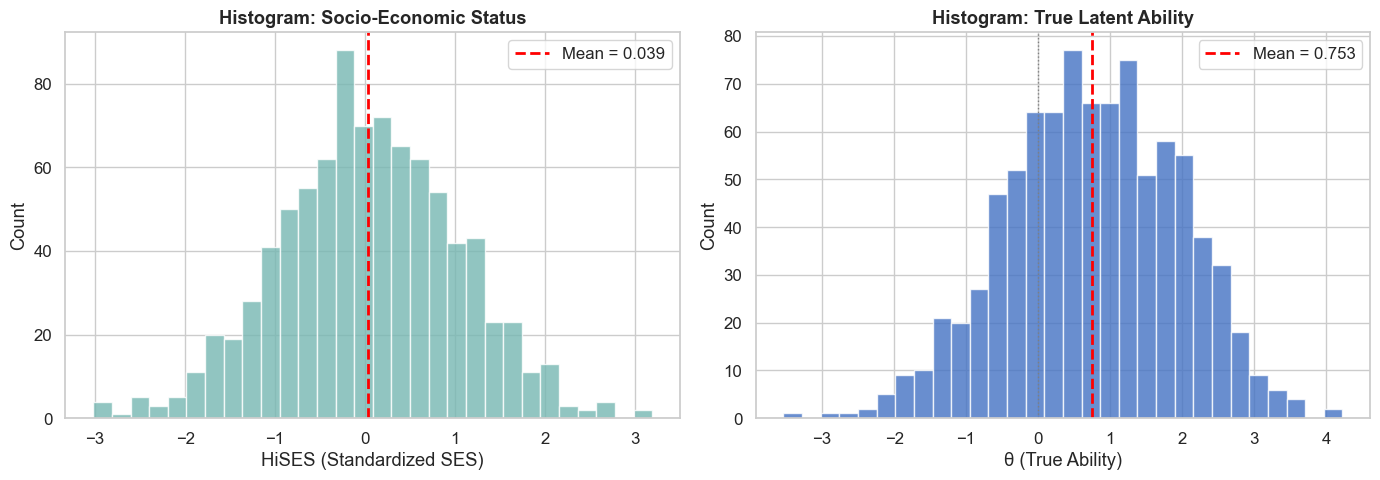

In [8]:
# ── Histograms ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(persons['hises'], bins=30, color='#76B7B2', edgecolor='white', alpha=0.8)
ax.axvline(persons['hises'].mean(), color='red', linestyle='--', lw=2,
           label=f"Mean = {persons['hises'].mean():.3f}")
ax.set_xlabel('HiSES (Standardized SES)'); ax.set_ylabel('Count')
ax.set_title('Histogram: Socio-Economic Status', fontweight='bold')
ax.legend()

ax = axes[1]
ax.hist(persons['theta_true'], bins=30, color='#4472C4', edgecolor='white', alpha=0.8)
ax.axvline(persons['theta_true'].mean(), color='red', linestyle='--', lw=2,
           label=f"Mean = {persons['theta_true'].mean():.3f}")
ax.axvline(0, color='gray', linestyle=':', lw=1)
ax.set_xlabel('θ (True Ability)'); ax.set_ylabel('Count')
ax.set_title('Histogram: True Latent Ability', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

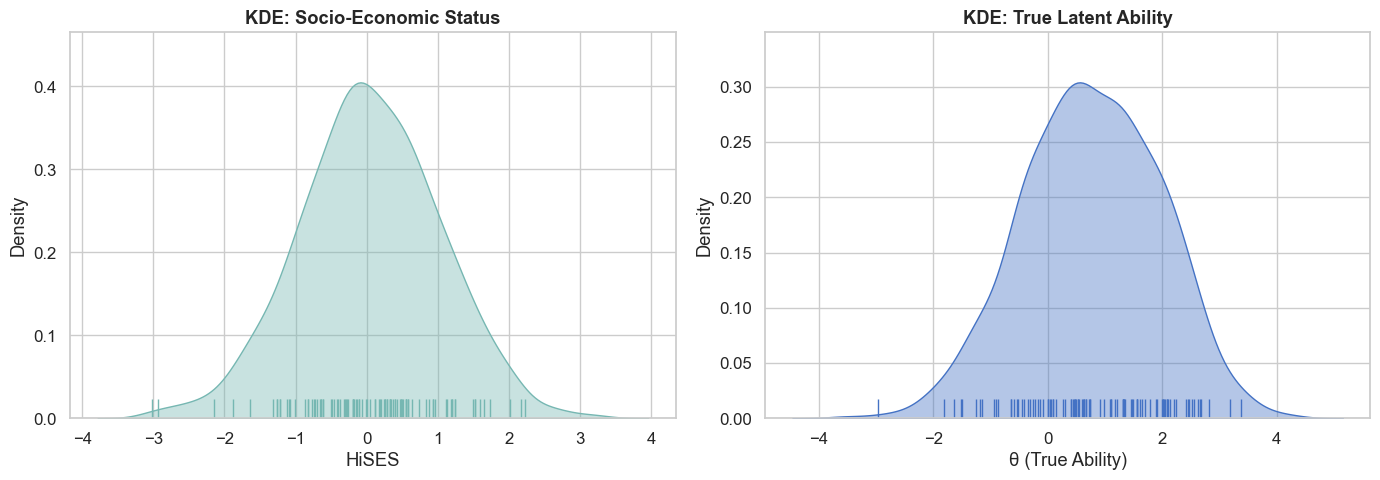

In [9]:
# ── KDE plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.kdeplot(data=persons, x='hises', fill=True, color='#76B7B2', alpha=0.4, ax=ax)
sns.rugplot(data=persons.sample(100, random_state=0), x='hises', color='#76B7B2', ax=ax, height=0.05)
ax.set_xlabel('HiSES'); ax.set_title('KDE: Socio-Economic Status', fontweight='bold')

ax = axes[1]
sns.kdeplot(data=persons, x='theta_true', fill=True, color='#4472C4', alpha=0.4, ax=ax)
sns.rugplot(data=persons.sample(100, random_state=0), x='theta_true', color='#4472C4', ax=ax, height=0.05)
ax.set_xlabel('θ (True Ability)'); ax.set_title('KDE: True Latent Ability', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Ability by Person Properties

How does true ability (θ) vary across gender and school program?

In [10]:
# Add readable labels
persons['Gender'] = persons['gender'].map({0: 'Female', 1: 'Male'})
persons['Program'] = persons['program'].map({1:'1-Hauptschule', 2:'2-Integrated',
                                              3:'3-Realschule', 4:'4-Gymnasium'})

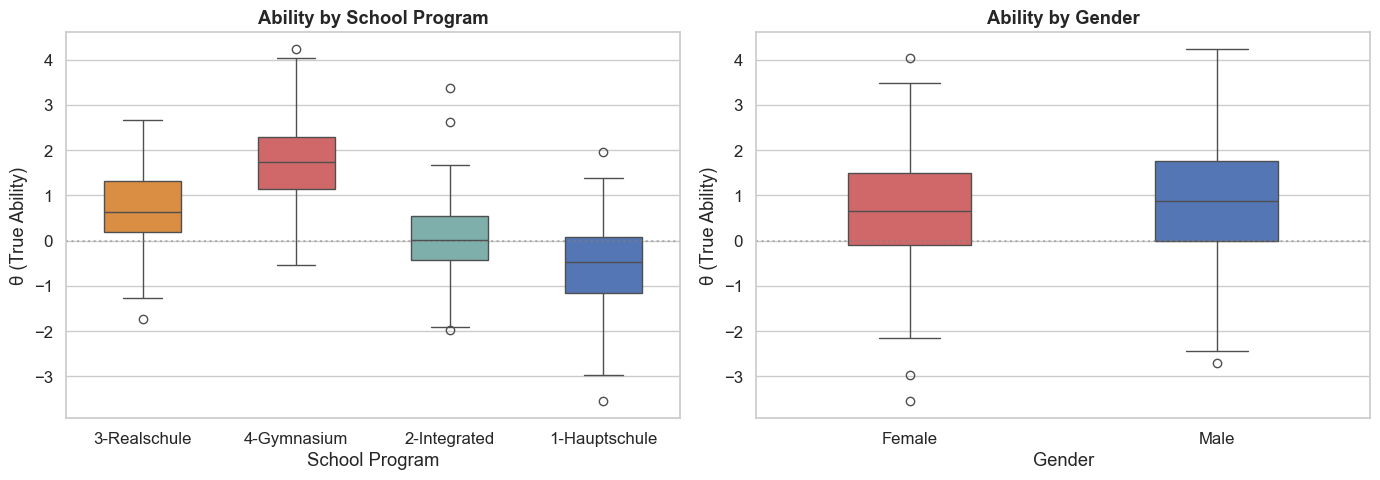

In [11]:
# ── Box plots: θ by Program and Gender ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.boxplot(data=persons, x='Program', y='theta_true', hue='Program',
            palette=colors_p, width=0.5, legend=False, ax=ax)
ax.set_xlabel('School Program'); ax.set_ylabel('θ (True Ability)')
ax.set_title('Ability by School Program', fontweight='bold')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

ax = axes[1]
sns.boxplot(data=persons, x='Gender', y='theta_true', hue='Gender',
            palette={'Female':'#E15759','Male':'#4472C4'}, width=0.4, legend=False, ax=ax)
ax.set_xlabel('Gender'); ax.set_ylabel('θ (True Ability)')
ax.set_title('Ability by Gender', fontweight='bold')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

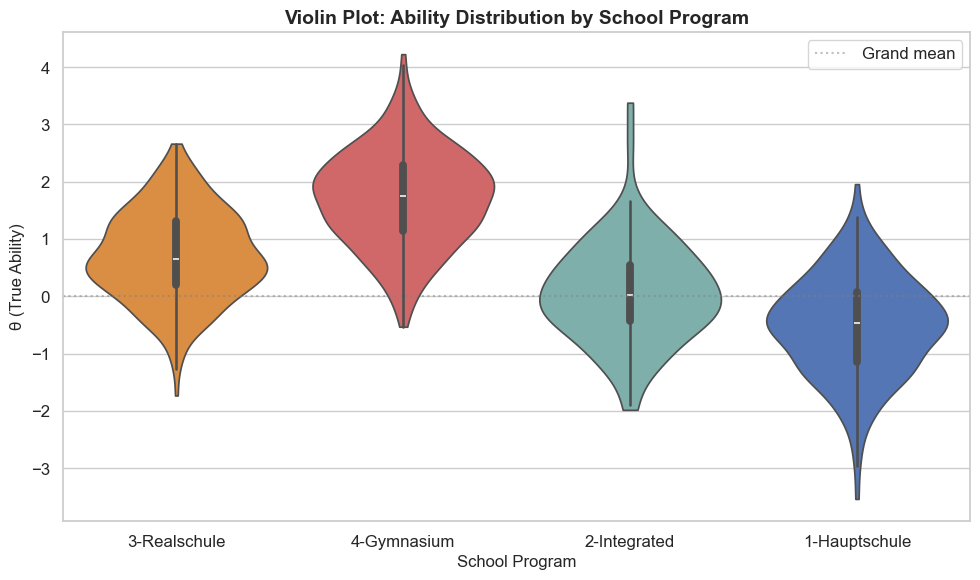

In [12]:
# ── Violin plots: θ by Program ──
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=persons, x='Program', y='theta_true', hue='Program',
               palette=colors_p, inner='box', cut=0, legend=False, ax=ax)
ax.set_xlabel('School Program', fontsize=12)
ax.set_ylabel('θ (True Ability)', fontsize=12)
ax.set_title('Violin Plot: Ability Distribution by School Program', fontweight='bold', fontsize=14)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5, label='Grand mean')
ax.legend()

plt.tight_layout()
plt.show()

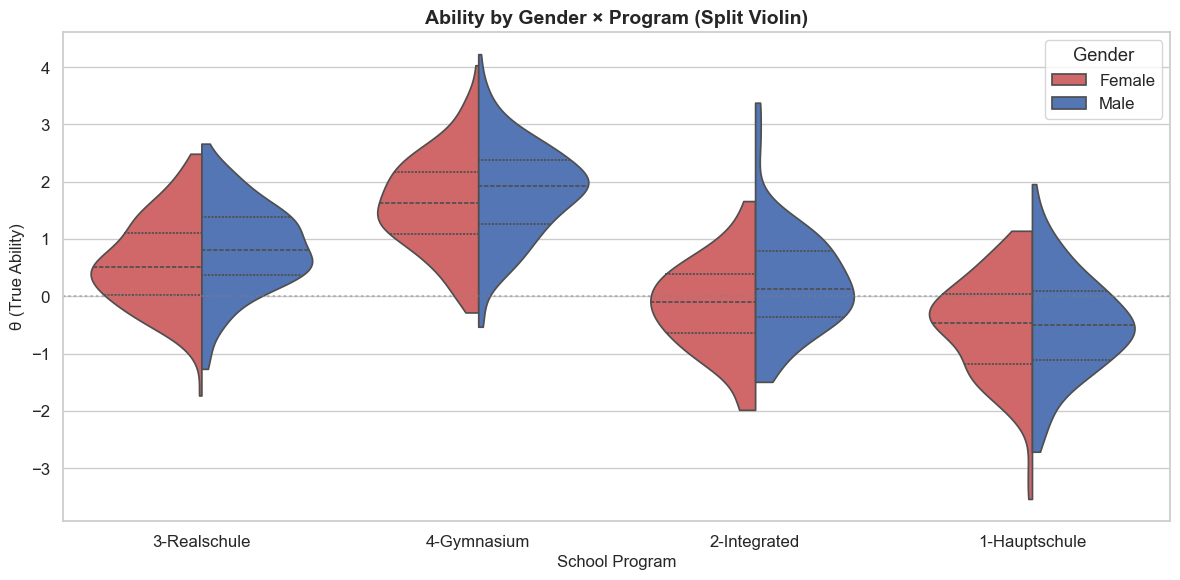

In [13]:
# ── Violin plot: θ by Gender × Program ──
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=persons, x='Program', y='theta_true', hue='Gender',
               split=True, inner='quart', palette={'Female':'#E15759','Male':'#4472C4'},
               cut=0, ax=ax)
ax.set_xlabel('School Program', fontsize=12)
ax.set_ylabel('θ (True Ability)', fontsize=12)
ax.set_title('Ability by Gender × Program (Split Violin)', fontweight='bold', fontsize=14)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.legend(title='Gender')

plt.tight_layout()
plt.show()

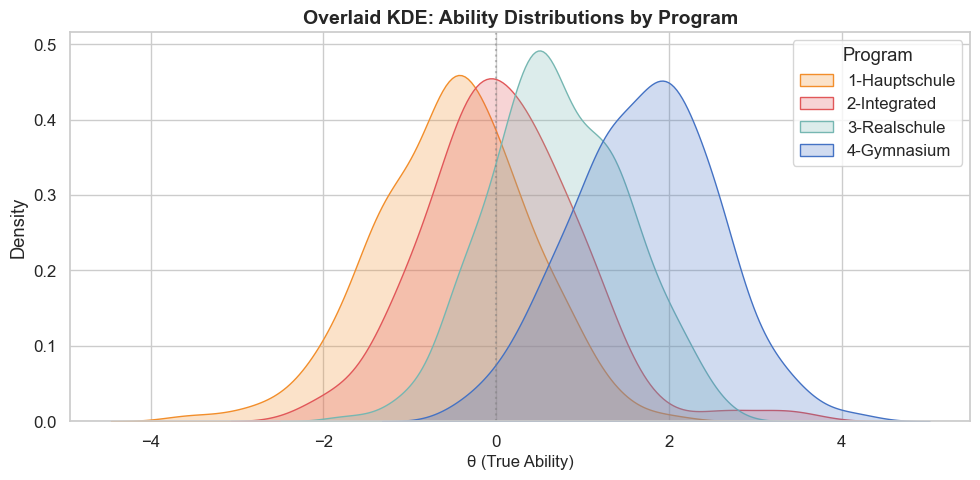

In [14]:
# ── KDE by Program (overlaid) ──
fig, ax = plt.subplots(figsize=(10, 5))

for prog, color in zip(['1-Hauptschule','2-Integrated','3-Realschule','4-Gymnasium'], colors_p):
    subset = persons[persons['Program'] == prog]
    sns.kdeplot(data=subset, x='theta_true', fill=True, alpha=0.25, color=color, label=prog, ax=ax)

ax.set_xlabel('θ (True Ability)', fontsize=12)
ax.set_title('Overlaid KDE: Ability Distributions by Program', fontweight='bold', fontsize=14)
ax.legend(title='Program')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. SES and Ability Relationship

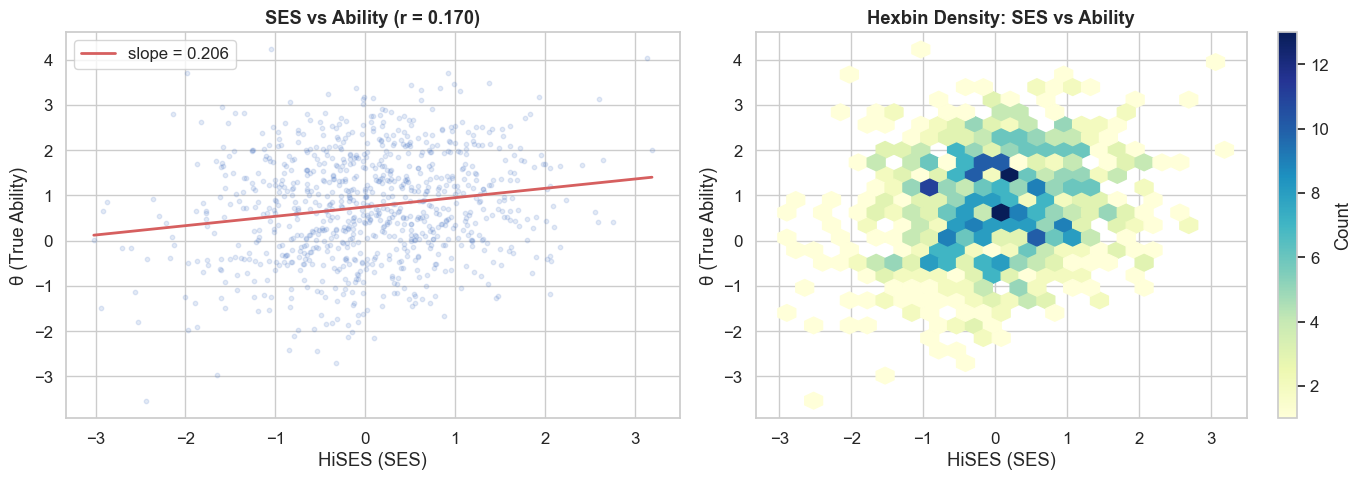

In [15]:
# ── Scatter: SES vs Ability ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(persons['hises'], persons['theta_true'], alpha=0.15, s=10, c='#4472C4')
# Trend line
z = np.polyfit(persons['hises'], persons['theta_true'], 1)
x_line = np.linspace(persons['hises'].min(), persons['hises'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=2, label=f'slope = {z[0]:.3f}')
r = np.corrcoef(persons['hises'], persons['theta_true'])[0,1]
ax.set_xlabel('HiSES (SES)'); ax.set_ylabel('θ (True Ability)')
ax.set_title(f'SES vs Ability (r = {r:.3f})', fontweight='bold')
ax.legend()

# Hexbin for density
ax = axes[1]
hb = ax.hexbin(persons['hises'], persons['theta_true'], gridsize=25, cmap='YlGnBu', mincnt=1)
ax.set_xlabel('HiSES (SES)'); ax.set_ylabel('θ (True Ability)')
ax.set_title(f'Hexbin Density: SES vs Ability', fontweight='bold')
plt.colorbar(hb, ax=ax, label='Count')

plt.tight_layout()
plt.show()

In [16]:
# ── Summary statistics by group ──
print('Mean θ by Program × Gender:')
summary = persons.groupby(['Program', 'Gender'])['theta_true'].agg(['mean','std','count'])
summary.columns = ['Mean θ', 'SD θ', 'N']
summary.round(3)

Mean θ by Program × Gender:


Mean θ   SD θ    N
Program       Gender                    
1-Hauptschule Female  -0.533  0.887   90
              Male    -0.499  0.880  102
2-Integrated  Female  -0.189  0.804   35
              Male     0.245  0.907   52
3-Realschule  Female   0.587  0.786  147
              Male     0.849  0.761  127
4-Gymnasium   Female   1.609  0.839  168
              Male     1.823  0.829  160

## 6. Key Observations

1. **Program effect is large**: Gymnasium students have much higher ability than Hauptschule students
2. **Gender effect is subtle**: mainly visible as an interaction with program level
3. **SES is positively correlated** with ability (as expected)
4. All distributions are roughly normal (by design — θ was generated from a normal)